In [57]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(ROOT / "src"))

from compare.plots import (
    plot_lines, plot_eer, plot_f1, plot_pareto, plot_loss_curves, plot_loss_vs_eer,
    plot_gmm_components, plot_gmm_diag_vs_full, plot_eer_by_target, _filter,
)

# Switch the active data source by uncommenting one line:
# df = pd.read_parquet(ROOT / "results" / "sweep_speech_latest.parquet"); TARGET_LABEL = "word"
# df = pd.read_parquet(ROOT / "results" / "sweep_pendigits_latest.parquet"); TARGET_LABEL = "digit"
df = pd.read_parquet(ROOT / "results" / "sweep_har_latest.parquet"); TARGET_LABEL = "subject"

# Train_n value for plots that pin to a single budget
FIXED_TRAIN_N = 45


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Slide 1: GMM-only comparison

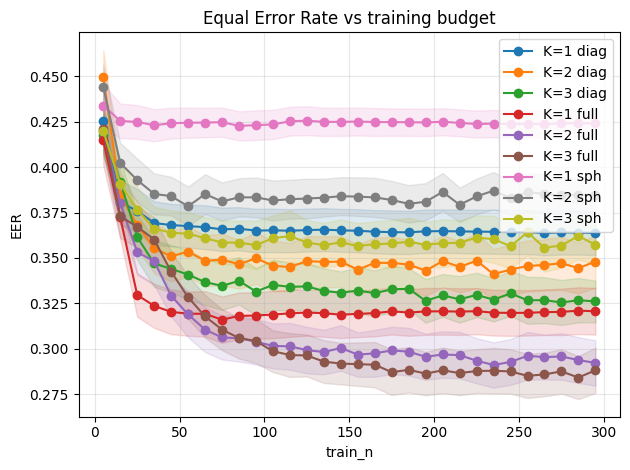

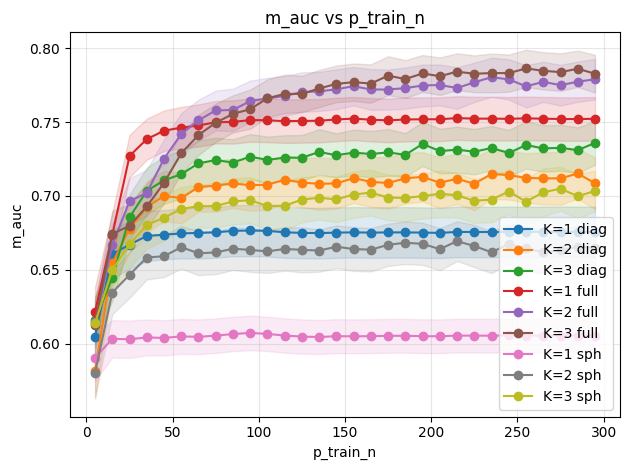

In [58]:
gmm_lines = [
    ("K=1 diag", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"}),
    ("K=2 diag", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"}),
    ("K=3 diag", {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "diag"}),
    ("K=1 full", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "full"}),
    ("K=2 full", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "full"}),
    ("K=3 full", {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "full"}),
    ("K=1 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "spherical"}),
    ("K=2 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "spherical"}),
    ("K=3 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "spherical"}),
]

plot_eer(df, lines=gmm_lines)
plot_lines(df, x="p_train_n", y="m_auc", lines=gmm_lines)

# Slide 1b: GMM covariance type comparison

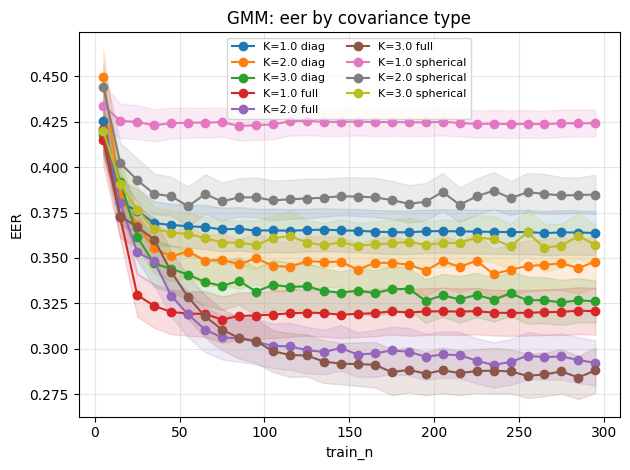

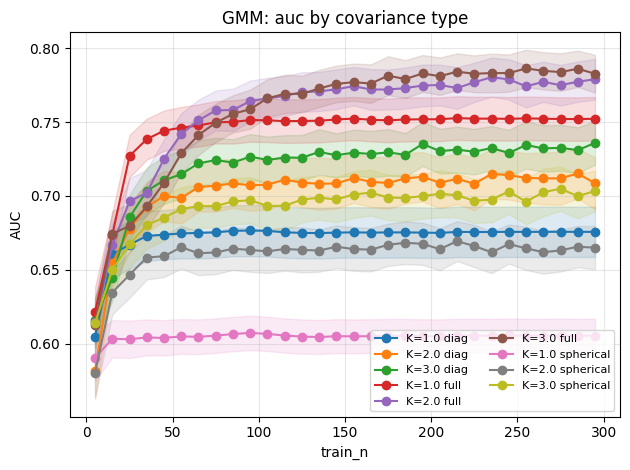

In [59]:
plot_gmm_diag_vs_full(df, y="m_eer")
plot_gmm_diag_vs_full(df, y="m_auc")
plt.show()

# Slide 1c: GMM optimal K

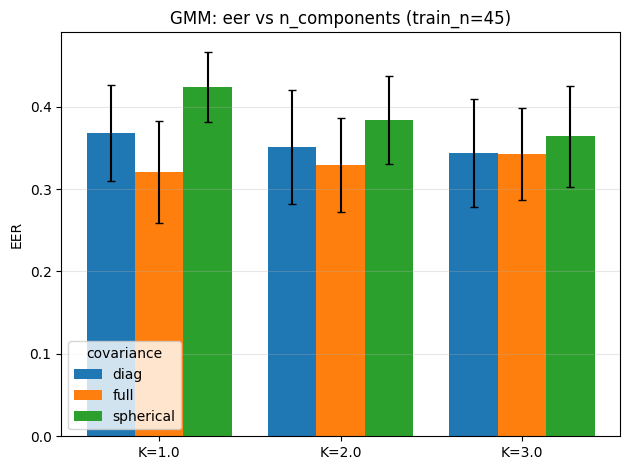

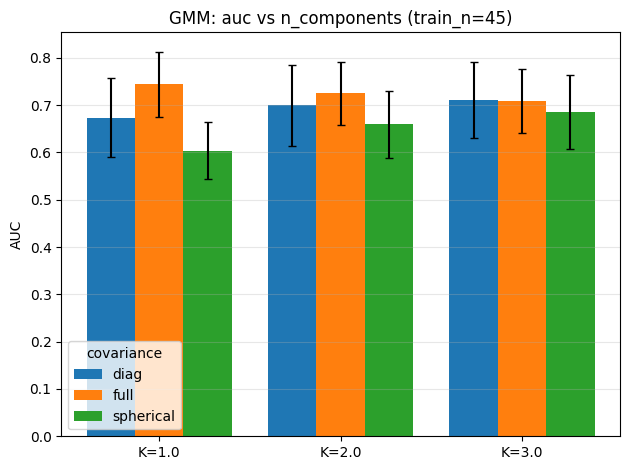

In [60]:
plot_gmm_components(df, y="m_eer", fixed_train_n=FIXED_TRAIN_N)
plot_gmm_components(df, y="m_auc", fixed_train_n=FIXED_TRAIN_N)
plt.show()

# Slide 1c-ci: GMM EER and AUC at fixed train_n with 95% CI

Horizontal error-bar plot of GMM configs' EER and AUC at a fixed `train_n`, with 95% confidence intervals across trials x target words.

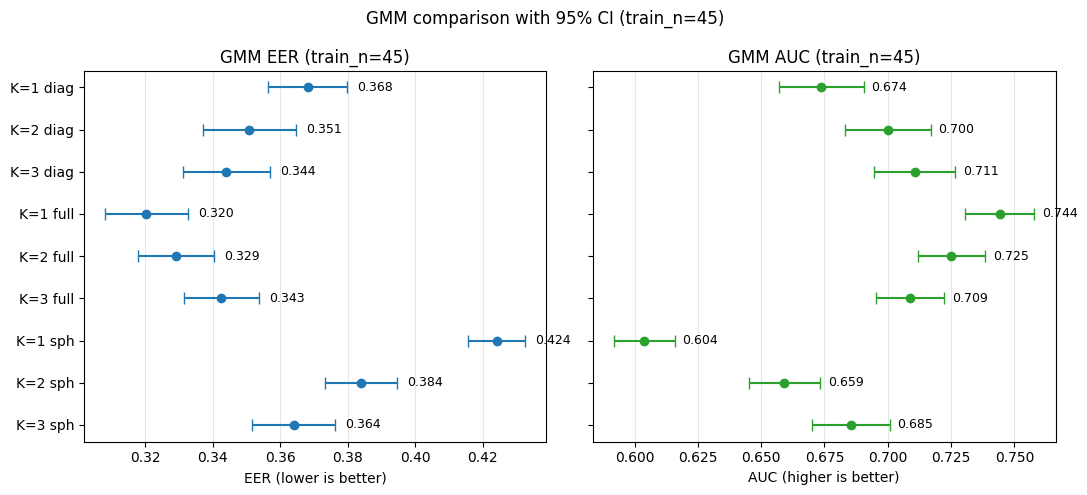

In [61]:
from scipy import stats as _stats
import numpy as np

GMM_CI_TRAIN_N = FIXED_TRAIN_N

gmm_ci_configs = [
    ("K=1 diag", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"}),
    ("K=2 diag", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"}),
    ("K=3 diag", {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "diag"}),
    ("K=1 full", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "full"}),
    ("K=2 full", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "full"}),
    ("K=3 full", {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "full"}),
    ("K=1 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "spherical"}),
    ("K=2 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "spherical"}),
    ("K=3 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "spherical"}),
]

sub_gmm_ci = df[df["p_train_n"] == GMM_CI_TRAIN_N]

def _mean_ci95(vals):
    vals = vals.dropna()
    n = len(vals)
    if n < 2:
        return (vals.mean() if n else float("nan"), 0.0)
    sem = vals.std(ddof=1) / np.sqrt(n)
    t_crit = _stats.t.ppf(0.975, df=n - 1)
    return vals.mean(), t_crit * sem

fig, (ax_eer, ax_auc) = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

for i, (label, where) in enumerate(gmm_ci_configs):
    s = _filter(sub_gmm_ci, where)
    if s.empty:
        continue
    m_eer, ci_eer = _mean_ci95(s["m_eer"])
    m_auc, ci_auc = _mean_ci95(s["m_auc"])
    ax_eer.errorbar(m_eer, i, xerr=ci_eer, fmt="o", color="tab:blue", capsize=4)
    ax_eer.text(m_eer + ci_eer + 0.003, i, f"{m_eer:.3f}", va="center", fontsize=9)
    ax_auc.errorbar(m_auc, i, xerr=ci_auc, fmt="o", color="tab:green", capsize=4)
    ax_auc.text(m_auc + ci_auc + 0.003, i, f"{m_auc:.3f}", va="center", fontsize=9)

ax_eer.set_yticks(range(len(gmm_ci_configs)))
ax_eer.set_yticklabels([c[0] for c in gmm_ci_configs])
ax_eer.set_xlabel("EER (lower is better)")
ax_eer.set_title(f"GMM EER (train_n={GMM_CI_TRAIN_N})")
ax_eer.invert_yaxis()
ax_eer.grid(axis="x", alpha=0.3)

ax_auc.set_xlabel("AUC (higher is better)")
ax_auc.set_title(f"GMM AUC (train_n={GMM_CI_TRAIN_N})")
ax_auc.grid(axis="x", alpha=0.3)

fig.suptitle(f"GMM comparison with 95% CI (train_n={GMM_CI_TRAIN_N})")
fig.tight_layout()
plt.show()


# Slide 1d: GMM EER per target class (by covariance type)


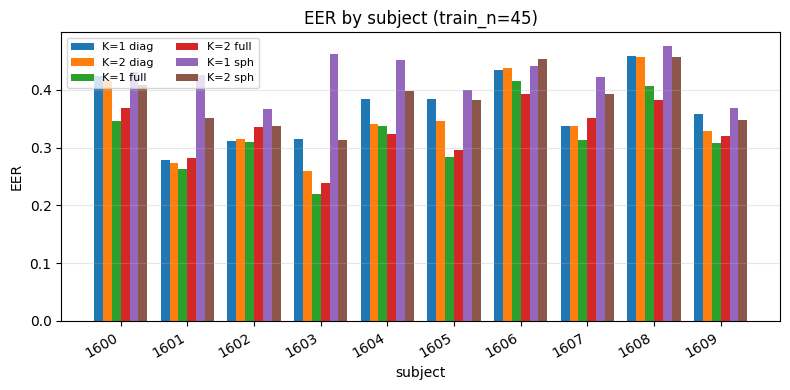

In [62]:
gmm_word_lines = [
    ("K=1 diag", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"}),
    ("K=2 diag", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"}),
    ("K=1 full", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "full"}),
    ("K=2 full", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "full"}),
    ("K=1 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "spherical"}),
    ("K=2 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "spherical"}),
]

plot_eer_by_target(df, gmm_word_lines, train_n=FIXED_TRAIN_N, target_label=TARGET_LABEL)
plt.show()


# Slide 1e: Statistical significance (paired t-tests)

In [63]:
import numpy as np
from scipy import stats

TRAIN_N = FIXED_TRAIN_N
sub = df[df["p_train_n"] == TRAIN_N]
idx = ["p_trial", "p_target_class"]

def paired_test(a_eer, b_eer):
    """Return (n, mean_diff, cohen_d, t, p) for b - a."""
    paired = pd.concat([a_eer.rename("a"), b_eer.rename("b")], axis=1).dropna()
    diff = paired["b"] - paired["a"]
    d = diff.mean() / diff.std()
    t, p = stats.ttest_rel(paired["b"], paired["a"])
    return len(paired), diff.mean(), d, t, p

def get_eer(where: dict):
    mask = pd.Series(True, index=sub.index)
    for k, v in where.items():
        if k not in sub.columns:
            return pd.Series(dtype=float)  # column absent: treat as no matching rows
        mask &= sub[k] == v
    return sub[mask].set_index(idx)["m_eer"]

# Define all configs to compare
configs = {
    "GMM K=1 diag": {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"},
    "GMM K=2 diag": {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"},
    "GMM K=3 diag": {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "diag"},
    "GMM K=1 full": {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "full"},
    "GMM K=2 full": {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "full"},
    "GMM K=3 full": {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "full"},
    "GMM K=1 sph":  {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "spherical"},
    "GMM K=2 sph":  {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "spherical"},
    "GMM K=3 sph":  {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "spherical"},
    "SmallAE": {"p_adapter": "SmallAEAdapter", "p_latent_dim": 8, "p_epochs": 100},
    "kNN k=1":  {"p_adapter": "KNNAdapter", "p_k": 1},
    "kNN k=2":  {"p_adapter": "KNNAdapter", "p_k": 2},
    "kNN k=3":  {"p_adapter": "KNNAdapter", "p_k": 3},
    "kNN k=4":  {"p_adapter": "KNNAdapter", "p_k": 4},
    "kNN k=5":  {"p_adapter": "KNNAdapter", "p_k": 5},
    "kNN k=6":  {"p_adapter": "KNNAdapter", "p_k": 6},
    "kNN k=7":  {"p_adapter": "KNNAdapter", "p_k": 7},
    "kNN k=8":  {"p_adapter": "KNNAdapter", "p_k": 8},
    "kNN k=9":  {"p_adapter": "KNNAdapter", "p_k": 9},
    "kNN k=10": {"p_adapter": "KNNAdapter", "p_k": 10},
}

# All pairwise comparisons
config_names = list(configs.keys())
rows = []
for i in range(len(config_names)):
    for j in range(i + 1, len(config_names)):
        a_name, b_name = config_names[i], config_names[j]
        a_eer = get_eer(configs[a_name])
        b_eer = get_eer(configs[b_name])
        if a_eer.empty or b_eer.empty:
            continue
        n, md, d, t, p = paired_test(a_eer, b_eer)
        rows.append({"A": a_name, "B": b_name, "n_pairs": n,
                      "mean_diff": md, "cohen_d": d, "t_stat": t, "p_value": p})

if rows:
    res = pd.DataFrame(rows)
    res["sig"] = res["p_value"].apply(lambda p: "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns")
    print(f"Paired t-tests on EER at train_n={TRAIN_N}  (is A better than B?)\n")
    print(res.to_string(index=False, float_format="%.4f"))
else:
    print(f"No matching config pairs found in data at train_n={TRAIN_N}."
          " Re-run the sweep with the configs above.")

Paired t-tests on EER at train_n=45  (is A better than B?)

           A            B  n_pairs  mean_diff  cohen_d   t_stat  p_value sig
GMM K=1 diag GMM K=2 diag      100    -0.0173  -0.4769  -4.7689   0.0000 ***
GMM K=1 diag GMM K=3 diag      100    -0.0241  -0.6944  -6.9439   0.0000 ***
GMM K=1 diag GMM K=1 full      100    -0.0478  -1.1606 -11.6059   0.0000 ***
GMM K=1 diag GMM K=2 full      100    -0.0390  -0.7443  -7.4428   0.0000 ***
GMM K=1 diag GMM K=3 full      100    -0.0256  -0.4775  -4.7746   0.0000 ***
GMM K=1 diag  GMM K=1 sph      100     0.0561   0.9983   9.9835   0.0000 ***
GMM K=1 diag  GMM K=2 sph      100     0.0159   0.3970   3.9702   0.0001 ***
GMM K=1 diag  GMM K=3 sph      100    -0.0042  -0.0843  -0.8425   0.4015  ns
GMM K=1 diag      SmallAE      100    -0.0054  -0.1344  -1.3443   0.1819  ns
GMM K=1 diag      kNN k=1      100    -0.0726  -1.3417 -13.4166   0.0000 ***
GMM K=1 diag      kNN k=2      100    -0.0540  -1.0234 -10.2344   0.0000 ***
GMM K=1 diag    

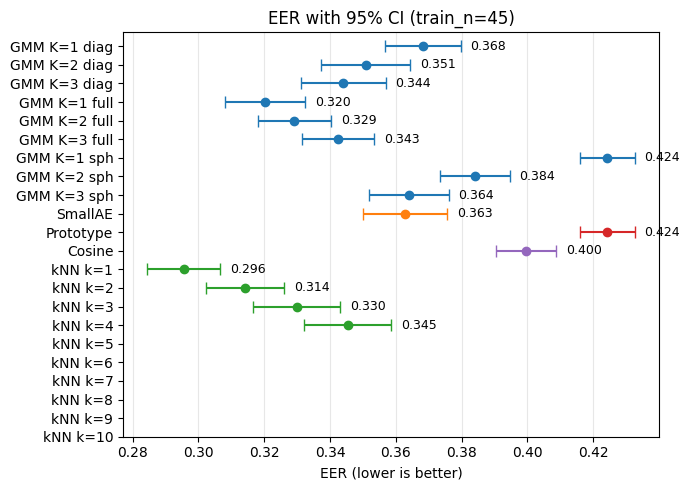

In [64]:
# 95% CI plot for EER at train_n=TRAIN_N (defined in previous cell)
ci_configs = [
    ("GMM K=1 diag", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"}),
    ("GMM K=2 diag", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"}),
    ("GMM K=3 diag", {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "diag"}),
    ("GMM K=1 full", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "full"}),
    ("GMM K=2 full", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "full"}),
    ("GMM K=3 full", {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "full"}),
    ("GMM K=1 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "spherical"}),
    ("GMM K=2 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "spherical"}),
    ("GMM K=3 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "spherical"}),
    ("SmallAE",  {"p_adapter": "SmallAEAdapter", "p_latent_dim": 8, "p_epochs": 100}),
    ("Prototype", {"p_adapter": "PrototypeAdapter"}),
    ("Cosine",    {"p_adapter": "CosineAdapter"}),
    ("kNN k=1",  {"p_adapter": "KNNAdapter", "p_k": 1}),
    ("kNN k=2",  {"p_adapter": "KNNAdapter", "p_k": 2}),
    ("kNN k=3",  {"p_adapter": "KNNAdapter", "p_k": 3}),
    ("kNN k=4",  {"p_adapter": "KNNAdapter", "p_k": 4}),
    ("kNN k=5",  {"p_adapter": "KNNAdapter", "p_k": 5}),
    ("kNN k=6",  {"p_adapter": "KNNAdapter", "p_k": 6}),
    ("kNN k=7",  {"p_adapter": "KNNAdapter", "p_k": 7}),
    ("kNN k=8",  {"p_adapter": "KNNAdapter", "p_k": 8}),
    ("kNN k=9",  {"p_adapter": "KNNAdapter", "p_k": 9}),
    ("kNN k=10", {"p_adapter": "KNNAdapter", "p_k": 10}),
]

colors = {
    "GMMAdapter": "tab:blue",
    "SmallAEAdapter": "tab:orange",
    "KNNAdapter": "tab:green",
    "PrototypeAdapter": "tab:red",
    "CosineAdapter": "tab:purple",
}

fig, ax = plt.subplots(figsize=(7, 5))
for i, (label, where) in enumerate(ci_configs):
    if any(k not in sub.columns for k in where):
        continue  # config references a column not present in current results
    mask = pd.Series(True, index=sub.index)
    for k, v in where.items():
        mask &= sub[k] == v
    vals = sub[mask]["m_eer"]
    if vals.empty:
        continue
    mean = vals.mean()
    ci = 1.96 * vals.std() / np.sqrt(len(vals))
    color = colors[where["p_adapter"]]
    ax.errorbar(mean, i, xerr=ci, fmt="o", color=color, capsize=4)
    ax.text(mean + ci + 0.003, i, f"{mean:.3f}", va="center", fontsize=9)

ax.set_yticks(range(len(ci_configs)))
ax.set_yticklabels([c[0] for c in ci_configs])
ax.set_xlabel("EER (lower is better)")
ax.set_title(f"EER with 95% CI (train_n={TRAIN_N})")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
plt.show()

# Slide 2: Best GMMs vs SmallAE vs kNN

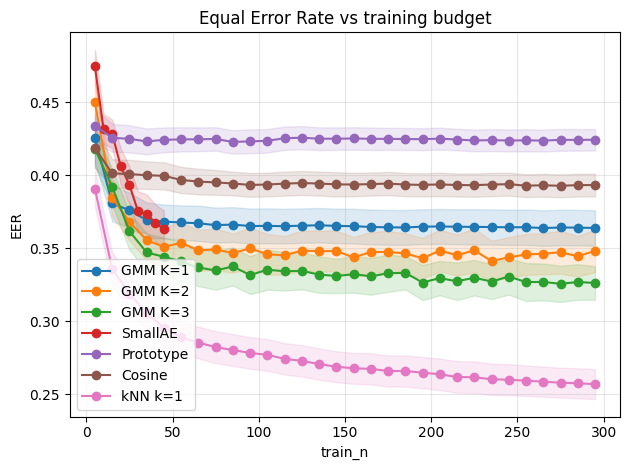

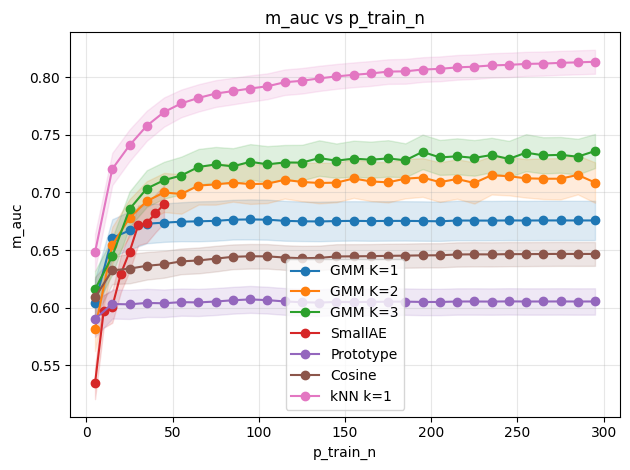

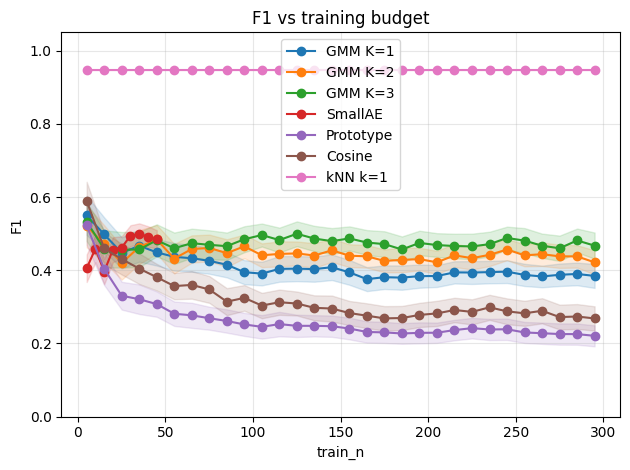

In [65]:
compare_lines = [
    ("GMM K=1",  {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"}),
    ("GMM K=2",  {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"}),
    ("GMM K=3",  {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "diag"}),
    ("SmallAE",  {"p_adapter": "SmallAEAdapter", "p_latent_dim": 8, "p_epochs": 100}),
    ("Prototype", {"p_adapter": "PrototypeAdapter"}),
    ("Cosine",    {"p_adapter": "CosineAdapter"}),
    ("kNN k=1",  {"p_adapter": "KNNAdapter", "p_k": 1}),
]

plot_eer(df, lines=compare_lines)
plot_lines(df, x="p_train_n", y="m_auc", lines=compare_lines)
plot_f1(df, lines=compare_lines)


# Slide 3: Training FLOPs comparison

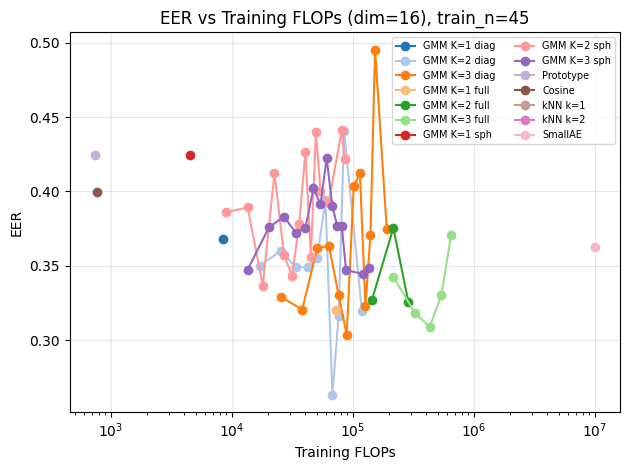

In [66]:
TRAIN_N = 45  # set to e.g. 50 to slice; None = all train_n

mac_lines = [
    # GMMs -- diag
    ("GMM K=1 diag", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"}),
    ("GMM K=2 diag", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"}),
    ("GMM K=3 diag", {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "diag"}),

    # GMMs -- full
    ("GMM K=1 full", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "full"}),
    ("GMM K=2 full", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "full"}),
    ("GMM K=3 full", {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "full"}),

    # GMMs -- spherical
    ("GMM K=1 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "spherical"}),
    ("GMM K=2 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "spherical"}),
    ("GMM K=3 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "spherical"}),

    # Simple-prototype baselines
    ("Prototype",    {"p_adapter": "PrototypeAdapter"}),
    ("Cosine",       {"p_adapter": "CosineAdapter"}),

    # kNNs
    ("kNN k=1",      {"p_adapter": "KNNAdapter", "p_k": 1}),
    ("kNN k=2",      {"p_adapter": "KNNAdapter", "p_k": 2}),

    # AEs
    ("SmallAE",  {"p_adapter": "SmallAEAdapter", "p_latent_dim": 8, "p_epochs": 100}),
]

from compare.plots import _filter, _agg
import matplotlib.cm as cm

colors = cm.tab20.colors  # 20 distinct colors

base_df = df if TRAIN_N is None else df[df["p_train_n"] == TRAIN_N]

for dim in sorted(base_df["p_embedding_dim"].unique()):
    fig, ax = plt.subplots()
    ci = 0
    for label, where in mac_lines:
        sub = _filter(base_df[base_df["p_embedding_dim"] == dim], where)
        if sub.empty:
            continue
        agg = _agg(sub, "m_training_flops", "m_eer")
        ax.plot(agg["m_training_flops"], agg["mean"], marker="o", label=label, color=colors[ci % len(colors)])
        ci += 1
    ax.set_xscale("log")
    ax.set_xlabel("Training FLOPs")
    ax.set_ylabel("EER")
    title = f"EER vs Training FLOPs (dim={dim})"
    if TRAIN_N is not None:
        title += f", train_n={TRAIN_N}"
    ax.set_title(title)
    ax.legend(fontsize=7, ncol=2)
    ax.grid(alpha=0.3)
    fig.tight_layout()

plt.show()

# Slide 3b: Inference FLOPs comparison

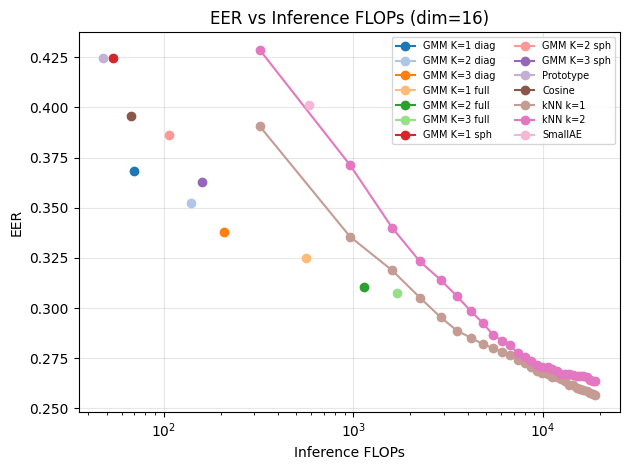

In [67]:
from compare.plots import _filter, _agg
import matplotlib.cm as cm

colors = cm.tab20.colors  # 20 distinct colors

for dim in sorted(df["p_embedding_dim"].unique()):
    fig, ax = plt.subplots()
    ci = 0
    for label, where in mac_lines:
        sub = _filter(df[df["p_embedding_dim"] == dim], where)
        if sub.empty:
            continue
        agg = _agg(sub, "m_inference_flops", "m_eer")
        ax.plot(agg["m_inference_flops"], agg["mean"], marker="o", label=label, color=colors[ci % len(colors)])
        ci += 1
    ax.set_xscale("log")
    ax.set_xlabel("Inference FLOPs")
    ax.set_ylabel("EER")
    ax.set_title(f"EER vs Inference FLOPs (dim={dim})")
    ax.legend(fontsize=7, ncol=2)
    ax.grid(alpha=0.3)
    fig.tight_layout()

plt.show()

# Slide 4: FLOPs-fair comparison (low-epoch SmallAE vs GMM)

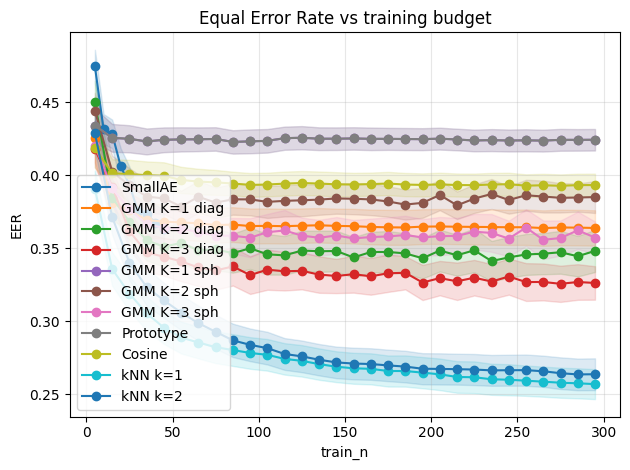

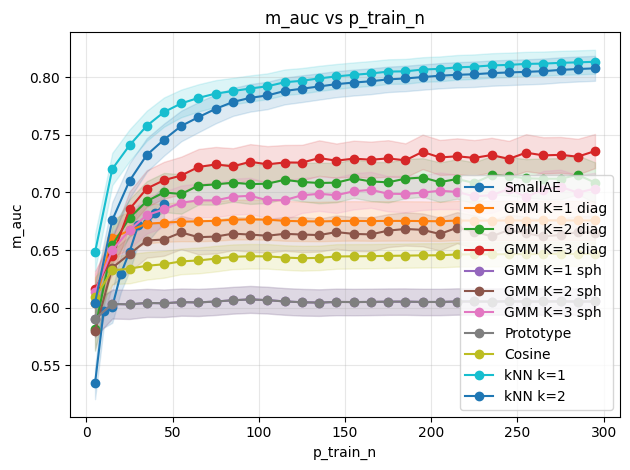

In [68]:
fair_lines = [
    ("SmallAE",  {"p_adapter": "SmallAEAdapter", "p_latent_dim": 8, "p_epochs": 100}),
    ("GMM K=1 diag",   {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"}),
    ("GMM K=2 diag",   {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"}),
    ("GMM K=3 diag",   {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "diag"}),
    ("GMM K=1 sph",    {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "spherical"}),
    ("GMM K=2 sph",    {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "spherical"}),
    ("GMM K=3 sph",    {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "spherical"}),
    ("Prototype",      {"p_adapter": "PrototypeAdapter"}),
    ("Cosine",         {"p_adapter": "CosineAdapter"}),
    ("kNN k=1",        {"p_adapter": "KNNAdapter", "p_k": 1}),
    ("kNN k=2",        {"p_adapter": "KNNAdapter", "p_k": 2}),
]

plot_eer(df, lines=fair_lines)
plot_lines(df, x="p_train_n", y="m_auc", lines=fair_lines)

# Slide 4b: ACC at FAR=5% vs enrollment budget

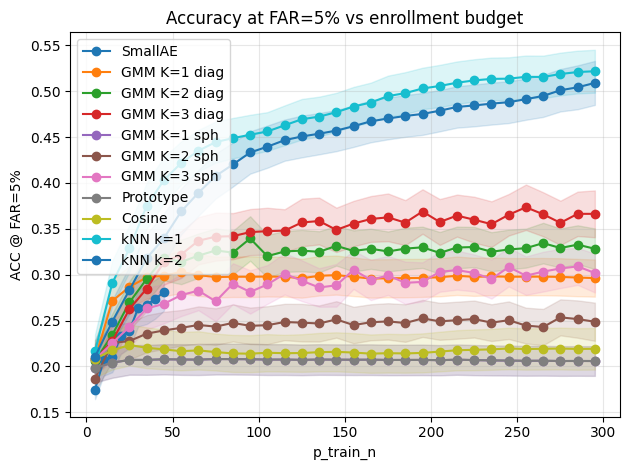

In [69]:
plot_lines(df, x="p_train_n", y="m_acc_at_far5", lines=fair_lines)
plt.ylabel("ACC @ FAR=5%")
plt.title("Accuracy at FAR=5% vs enrollment budget")
plt.show()

# Slide 5: Training FLOPs (low-epoch SmallAE vs GMM)

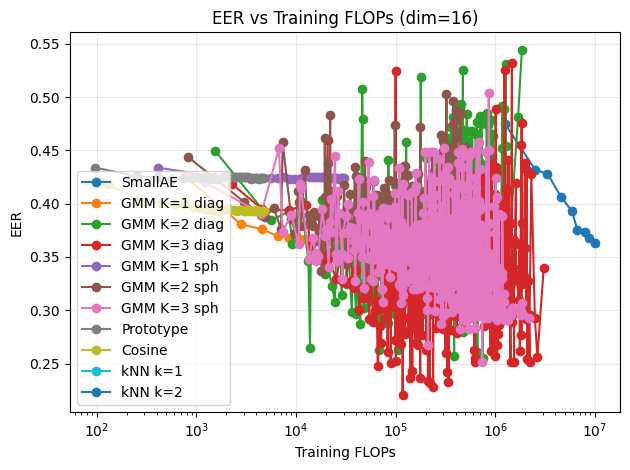

In [70]:
for dim in sorted(df["p_embedding_dim"].unique()):
    fig, ax = plt.subplots()
    for label, where in fair_lines:
        from compare.plots import _filter, _agg
        sub = _filter(df[df["p_embedding_dim"] == dim], where)
        if sub.empty:
            continue
        agg = _agg(sub, "m_training_flops", "m_eer")
        ax.plot(agg["m_training_flops"], agg["mean"], marker="o", label=label)
    ax.set_xscale("log")
    ax.set_xlabel("Training FLOPs")
    ax.set_ylabel("EER")
    ax.set_title(f"EER vs Training FLOPs (dim={dim})")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()

plt.show()

# Slide 5b: Inference FLOPs (low-epoch SmallAE vs GMM)

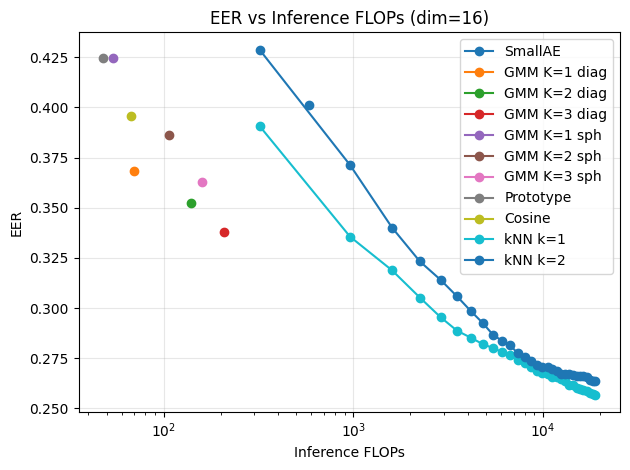

In [71]:
for dim in sorted(df["p_embedding_dim"].unique()):
    fig, ax = plt.subplots()
    for label, where in fair_lines:
        from compare.plots import _filter, _agg
        sub = _filter(df[df["p_embedding_dim"] == dim], where)
        if sub.empty:
            continue
        agg = _agg(sub, "m_inference_flops", "m_eer")
        ax.plot(agg["m_inference_flops"], agg["mean"], marker="o", label=label)
    ax.set_xscale("log")
    ax.set_xlabel("Inference FLOPs")
    ax.set_ylabel("EER")
    ax.set_title(f"EER vs Inference FLOPs (dim={dim})")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()

plt.show()

# Slide 6: EER variance across target classes


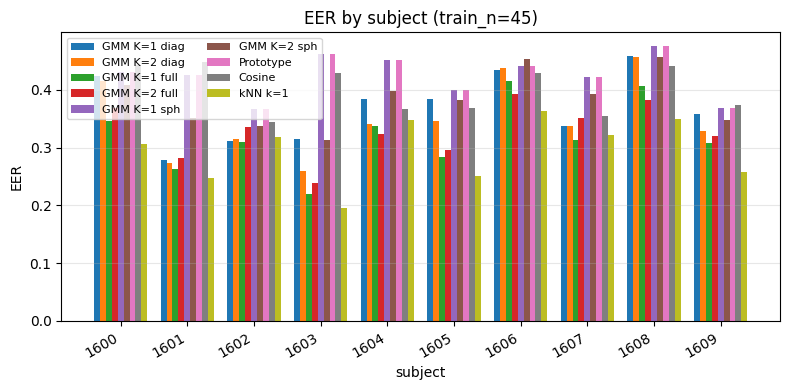

In [72]:
target_lines = [
    ("GMM K=1 diag", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"}),
    ("GMM K=2 diag", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"}),
    ("GMM K=1 full", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "full"}),
    ("GMM K=2 full", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "full"}),
    ("GMM K=1 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "spherical"}),
    ("GMM K=2 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "spherical"}),
    ("Prototype", {"p_adapter": "PrototypeAdapter"}),
    ("Cosine",    {"p_adapter": "CosineAdapter"}),
    ("kNN k=1",   {"p_adapter": "KNNAdapter", "p_k": 1}),
]

# EER per target at fixed train_n -- shows which targets are systematically harder.
plot_eer_by_target(df, target_lines, train_n=FIXED_TRAIN_N, target_label=TARGET_LABEL)
plt.show()


# Slide 7: Pareto frontier — iso-FLOP comparison

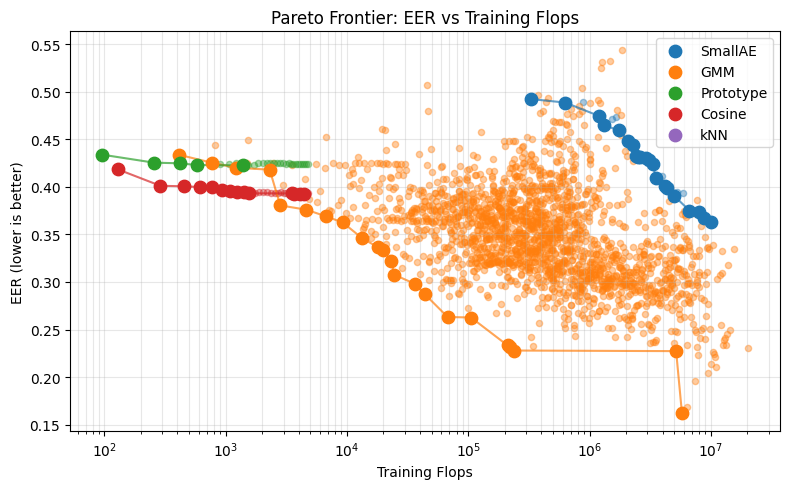

In [73]:
from compare.plots import plot_pareto

pareto_lines = [
    ("SmallAE",   {"p_adapter": "SmallAEAdapter"}),
    ("GMM",       {"p_adapter": "GMMAdapter"}),
    ("Prototype", {"p_adapter": "PrototypeAdapter"}),
    ("Cosine",    {"p_adapter": "CosineAdapter"}),
    ("kNN",       {"p_adapter": "KNNAdapter"}),
]

plot_pareto(df, lines=pareto_lines)
plt.show()

# Slide 7b: Pareto frontier — inference FLOPs

# Slide 8b: threshold_mode — val split vs full-budget training threshold

Does withholding a val split hurt the AE in the micro-data regime?
Compare `threshold_mode=val` (25% held out, threshold on val scores) vs
`threshold_mode=train` (full budget for training, threshold on train scores).

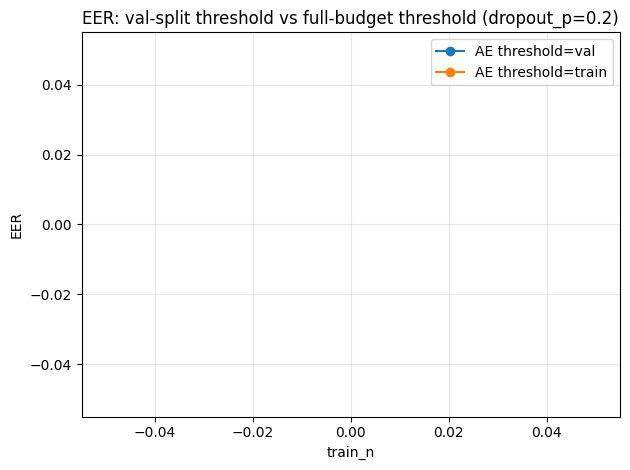

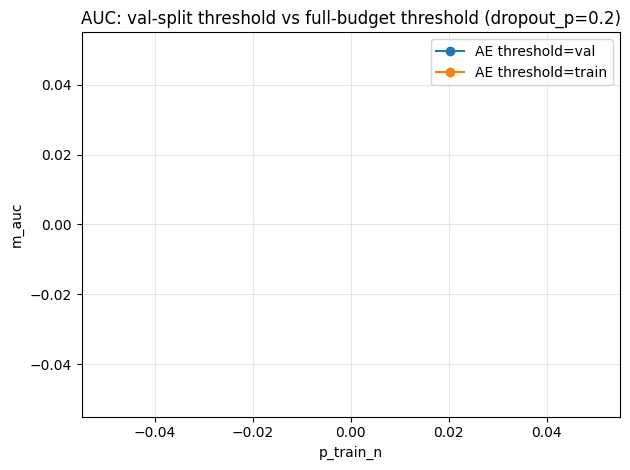

In [74]:
if "p_threshold_mode" not in df.columns:
    print("Skipping threshold_mode ablation: column 'p_threshold_mode' not present in current results.")
else:
    # Threshold-mode ablation: pin dropout_p=0.2 so only threshold_mode varies.
    threshold_lines = [
        ("AE threshold=val",   {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 30, "p_dropout_p": 0.2, "p_threshold_mode": "val"}),
        ("AE threshold=train", {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 30, "p_dropout_p": 0.2, "p_threshold_mode": "train"}),
    ]

    plot_eer(df, lines=threshold_lines)
    plt.title("EER: val-split threshold vs full-budget threshold (dropout_p=0.2)")

    plot_lines(df, x="p_train_n", y="m_auc", lines=threshold_lines)
    plt.title("AUC: val-split threshold vs full-budget threshold (dropout_p=0.2)")

    plt.show()

# Slide 8c: dropout — no dropout vs dropout_p=0.2

Does denoising regularisation (dropout during training) help the AE in the micro-data regime?

In [75]:
if "p_dropout_p" not in df.columns:
    print("Skipping dropout ablation: column 'p_dropout_p' not present in current results.")
else:
    # Dropout ablation: pin threshold_mode=train so only dropout varies.
    dropout_lines = [
        ("AE no-dropout",    {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 30, "p_dropout_p": 0.0, "p_threshold_mode": "train"}),
        ("AE dropout_p=0.2", {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 30, "p_dropout_p": 0.2, "p_threshold_mode": "train"}),
    ]

    plot_eer(df, lines=dropout_lines)
    plt.title("EER: no dropout vs dropout_p=0.2 (threshold_mode=train)")

    plot_lines(df, x="p_train_n", y="m_auc", lines=dropout_lines)
    plt.title("AUC: no dropout vs dropout_p=0.2 (threshold_mode=train)")

    plt.show()

Skipping dropout ablation: column 'p_dropout_p' not present in current results.


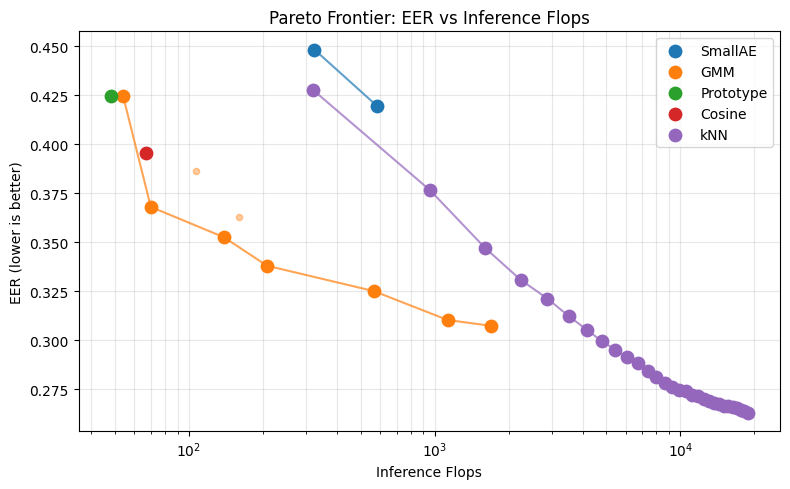

In [76]:
plot_pareto(df, lines=pareto_lines, x="m_inference_flops")
plt.show()

# Slide 8: AE training convergence

TODO: FIXME: the x axis is the percentage of the training wrt the number of iterations.
Make sure to consider this. This should be fixed.

/Users/alberto/Gits/tinygmm/src/compare/plots.py:325: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


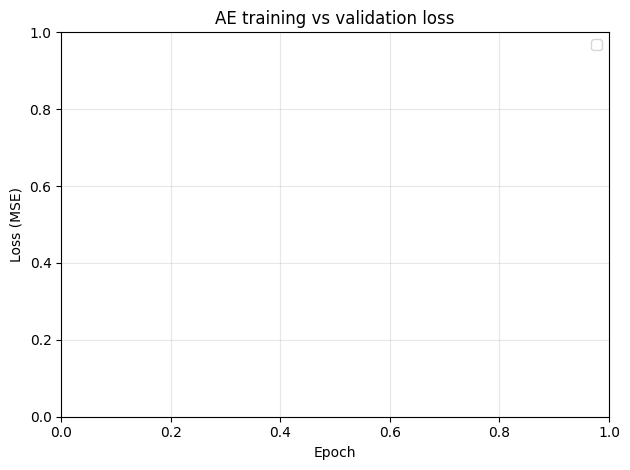

In [77]:
from compare.plots import plot_loss_curves, plot_loss_vs_eer

# Loss curves: is training still improving at the last epoch?
# Each checkpoint is at 20%, 40%, 60%, 80%, 100% of training.
# A line still dropping at x=1.0 means the adapter needs more epochs.
loss_lines = [
    # ("ep=10",  {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 10}),
    # ("ep=20",  {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 20}),
    ("ep=30", {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 30}),
]

plot_loss_curves(df, lines=loss_lines)
plt.show()

# Final test: held-out test classes

Results from `python -m src.compare.test_eval`. Each provider's reserved test classes are scored against each other:
- speech: 5 held-out words (`visual, five, seven, no, off`)
- HAR: 5 held-out subjects (`1610..1614`)

In [78]:
import numpy as np
# test_df = pd.read_parquet(ROOT / "results" / "test_speech.parquet")  # speech
test_df = pd.read_parquet(ROOT / "results" / "test_har.parquet")     # HAR
print(f"Loaded {len(test_df)} rows | adapters: {test_df['p_adapter'].unique().tolist()}")
test_df.head()

Loaded 2000 rows | adapters: ['GMMAdapter', 'SmallAEAdapter', 'CosineAdapter', 'PrototypeAdapter']


,p_split,p_trial,p_embedding_dim,p_target_class,p_other_classes,p_adapter,p_n_components,p_covariance_type,p_train_n,m_recall,...,m_val_loss_1,m_val_loss_2,m_val_loss_3,m_val_loss_4,m_val_loss_5,m_train_loss_1,m_train_loss_2,m_train_loss_3,m_train_loss_4,m_train_loss_5
0,test,0,16,1610,1611|1612|1613|1614,GMMAdapter,1.0,diag,5,0.391482,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,test,0,16,1610,1611|1612|1613|1614,SmallAEAdapter,NaN,NaN,5,0.043407,...,9.148636,8.126251,7.19222,6.2734,5.413458,2.504843,2.169868,1.878757,1.598946,1.334792
2,test,0,16,1610,1611|1612|1613|1614,CosineAdapter,NaN,NaN,5,0.536446,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,test,0,16,1610,1611|1612|1613|1614,PrototypeAdapter,NaN,NaN,5,0.074529,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,test,0,16,1610,1611|1612|1613|1614,GMMAdapter,1.0,diag,15,0.312039,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Summary metrics (mean +/- std across trials x target words)

In [79]:
metrics = ["m_eer", "m_auc", "m_auprc", "m_f1", "m_acc_at_far5"]
metrics = [m for m in metrics if m in test_df.columns]
summary = test_df.groupby("p_adapter")[metrics].agg(["mean", "std"]).round(4)
summary

m_eer           m_auc         m_auprc            m_f1  \
                    mean     std    mean     std    mean     std    mean   
p_adapter                                                                  
CosineAdapter     0.4243  0.0870  0.6027  0.0967  0.8614  0.0408  0.4219   
GMMAdapter        0.3992  0.0668  0.6422  0.0852  0.8815  0.0424  0.4880   
PrototypeAdapter  0.4409  0.0767  0.5821  0.0914  0.8489  0.0486  0.3535   
SmallAEAdapter    0.3909  0.0756  0.6601  0.1028  0.8855  0.0470  0.4760   

                         m_acc_at_far5          
                     std          mean     std  
p_adapter                                       
CosineAdapter     0.2056        0.2990  0.0692  
GMMAdapter        0.1986        0.3801  0.1192  
PrototypeAdapter  0.2325        0.3064  0.0830  
SmallAEAdapter    0.1959        0.3783  0.0994

## EER vs enrollment budget

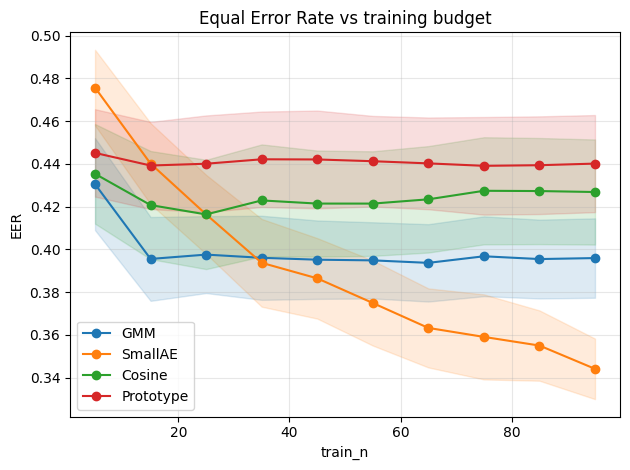

In [80]:
test_lines = [
    ("GMM",       {"p_adapter": "GMMAdapter"}),
    ("SmallAE",   {"p_adapter": "SmallAEAdapter"}),
    ("Cosine",    {"p_adapter": "CosineAdapter"}),
    ("Prototype", {"p_adapter": "PrototypeAdapter"}),
]
plot_eer(test_df, lines=test_lines)
plt.show()

## EER bar chart with 95% CI

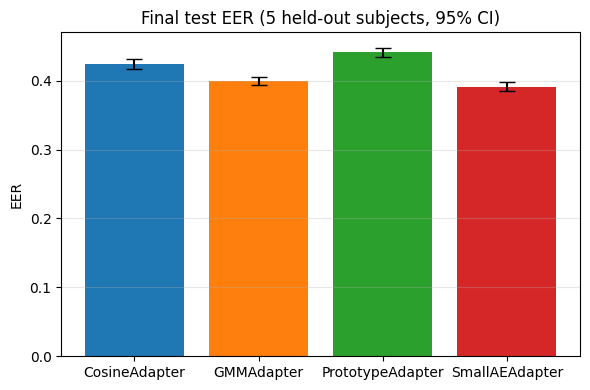

In [81]:
from scipy import stats as _stats

fig, ax = plt.subplots(figsize=(6, 4))
adapters = sorted(test_df["p_adapter"].unique())
means, margins = [], []
for a in adapters:
    vals = test_df.loc[test_df["p_adapter"] == a, "m_eer"].dropna()
    n = len(vals)
    m = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(n)
    t_crit = _stats.t.ppf(0.975, df=n - 1)
    means.append(m)
    margins.append(t_crit * sem)

colors = plt.get_cmap("tab10").colors[:len(adapters)]
ax.bar(adapters, means, yerr=margins, capsize=6, color=colors)
ax.set_ylabel("EER")
ax.set_title(f"Final test EER (5 held-out {TARGET_LABEL}s, 95% CI)")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

## Paired t-test: GMM vs AE on EER

In [82]:
idx = ["p_trial", "p_target_class"]
# Multiple GMM configs / train_n per (trial, target) -> mean within adapter first.
gmm_eer = test_df[test_df["p_adapter"] == "GMMAdapter"].groupby(idx)["m_eer"].mean()
ae_eer  = test_df[test_df["p_adapter"] == "SmallAEAdapter"].groupby(idx)["m_eer"].mean()
paired = pd.concat([gmm_eer.rename("gmm"), ae_eer.rename("ae")], axis=1).dropna()
diff = paired["ae"] - paired["gmm"]
t, p = _stats.ttest_rel(paired["ae"], paired["gmm"])
cohen_d = diff.mean() / diff.std(ddof=1)
print(f"n={len(paired)}  mean(AE-GMM)={diff.mean():+.4f}  cohen_d={cohen_d:+.3f}  t={t:+.3f}  p={p:.4g}")

n=50  mean(AE-GMM)=-0.0083  cohen_d=-0.536  t=-3.789  p=0.000415


## EER distribution (boxplot)

Distribution across all 5 target words x 10 trials = 50 runs per adapter.

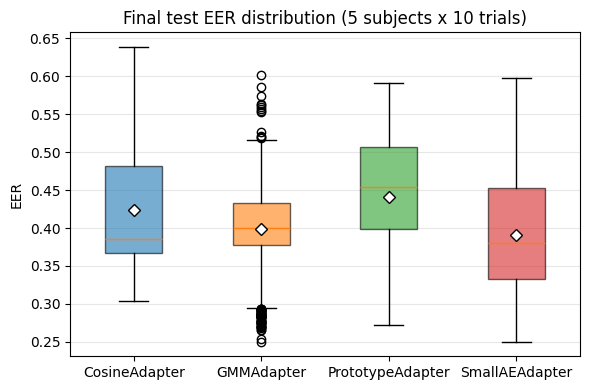

In [83]:
fig, ax = plt.subplots(figsize=(6, 4))
adapters = sorted(test_df["p_adapter"].unique())
data = [test_df.loc[test_df["p_adapter"] == a, "m_eer"].dropna().values for a in adapters]
bp = ax.boxplot(data, tick_labels=adapters, patch_artist=True, showmeans=True,
                meanprops={"marker": "D", "markerfacecolor": "white", "markeredgecolor": "black"})
colors = plt.get_cmap("tab10").colors[:len(adapters)]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel("EER")
ax.set_title(f"Final test EER distribution (5 {TARGET_LABEL}s x 10 trials)")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

## FAR vs Recall scatter

One point per (trial, target_word) — shows operating-point calibration spread.

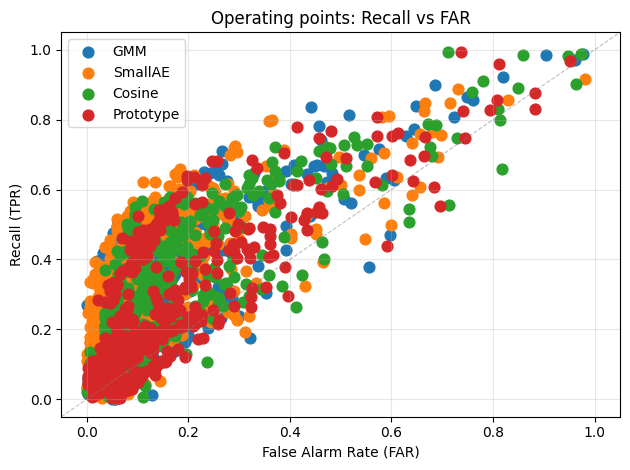

In [84]:
from compare.plots import plot_far_recall

test_lines = [
    ("GMM",       {"p_adapter": "GMMAdapter"}),
    ("SmallAE",   {"p_adapter": "SmallAEAdapter"}),
    ("Cosine",    {"p_adapter": "CosineAdapter"}),
    ("Prototype", {"p_adapter": "PrototypeAdapter"}),
]
plot_far_recall(test_df, lines=test_lines)
plt.show()